## Analysis of TR vs Te

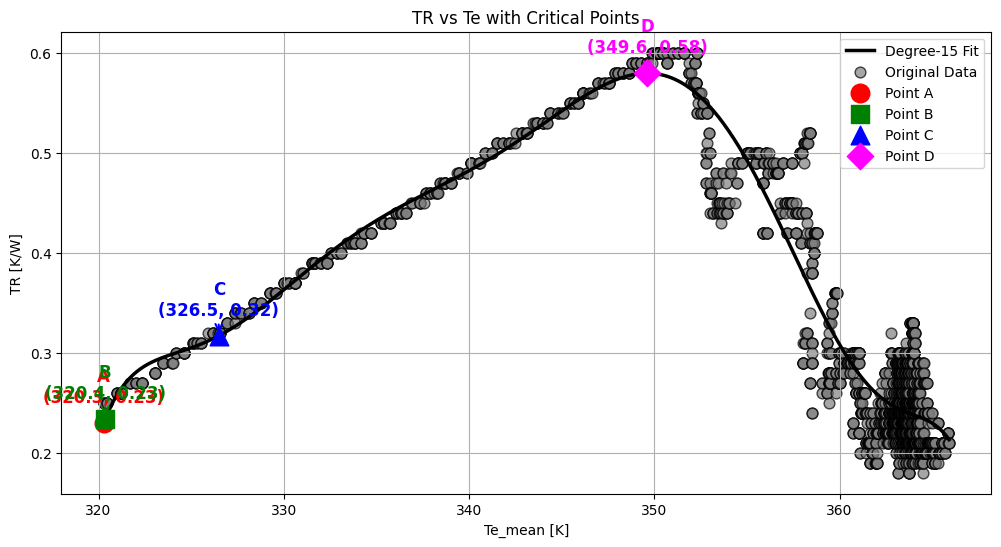

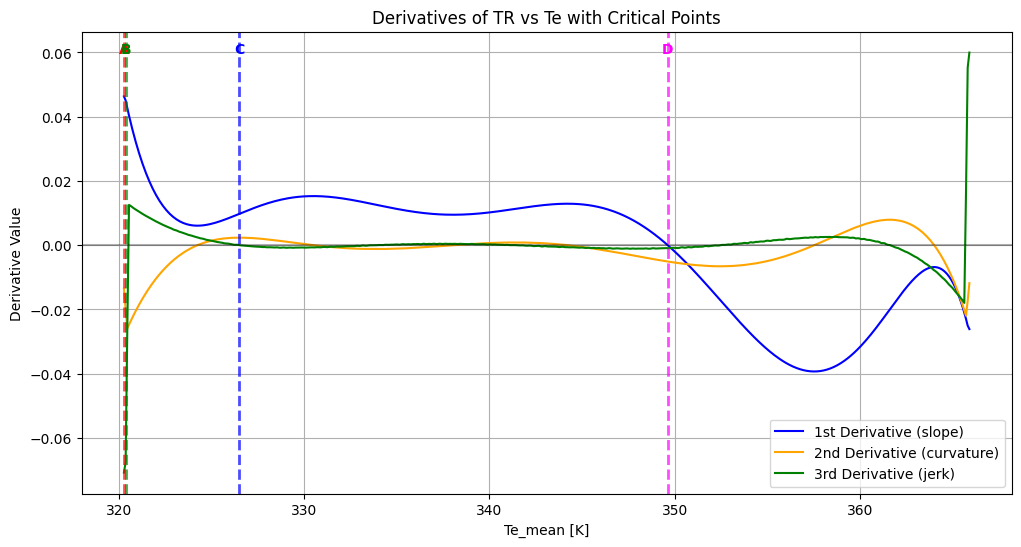

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

def optimize_polynomial_degree(Te, Y, max_degree=15, min_degree=5, cv_folds=5):
    degrees = range(min_degree, min(max_degree + 1, len(Te) // 3))
    rmse_scores, aic_scores, bic_scores, r2_scores = [], [], [], []
    Te_reshaped = Te.reshape(-1, 1)
    for degree in degrees:
        try:
            poly_pipeline = Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('linear', LinearRegression())
            ])
            cv_scores = cross_val_score(poly_pipeline, Te_reshaped, Y, cv=min(cv_folds, len(Te)//2), scoring='neg_root_mean_squared_error')
            rmse_cv = -cv_scores.mean()
            rmse_scores.append(rmse_cv)
            poly_pipeline.fit(Te_reshaped, Y)
            Y_pred = poly_pipeline.predict(Te_reshaped)
            mse = mean_squared_error(Y, Y_pred)
            n = len(Y)
            k = degree + 1
            ss_res = np.sum((Y - Y_pred) ** 2)
            ss_tot = np.sum((Y - np.mean(Y)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            r2_scores.append(r2)
            aic = n * np.log(mse) + 2 * k
            bic = n * np.log(mse) + k * np.log(n)
            aic_scores.append(aic)
            bic_scores.append(bic)
        except Exception:
            rmse_scores.append(float('inf'))
            aic_scores.append(float('inf'))
            bic_scores.append(float('inf'))
            r2_scores.append(-float('inf'))
    degrees = np.array(degrees)
    rmse_scores = np.array(rmse_scores)
    aic_scores = np.array(aic_scores)
    bic_scores = np.array(bic_scores)
    r2_scores = np.array(r2_scores)
    valid_idx = np.isfinite(rmse_scores)
    if not np.any(valid_idx):
        return {'optimal_degree': 5, 'method': 'default', 'rmse': float('inf')}
    best_rmse_idx = np.argmin(rmse_scores[valid_idx])
    best_aic_idx = np.argmin(aic_scores[valid_idx])
    best_bic_idx = np.argmin(bic_scores[valid_idx])
    best_rmse_degree = degrees[valid_idx][best_rmse_idx]
    best_aic_degree = degrees[valid_idx][best_aic_idx]
    best_bic_degree = degrees[valid_idx][best_bic_idx]
    rmse_norm = (rmse_scores - np.min(rmse_scores[valid_idx])) / (np.max(rmse_scores[valid_idx]) - np.min(rmse_scores[valid_idx]) + 1e-10)
    aic_norm = (aic_scores - np.min(aic_scores[valid_idx])) / (np.max(aic_scores[valid_idx]) - np.min(aic_scores[valid_idx]) + 1e-10)
    composite_scores = 0.6 * rmse_norm + 0.4 * aic_norm
    best_composite_idx = np.argmin(composite_scores[valid_idx])
    best_composite_degree = degrees[valid_idx][best_composite_idx]
    optimal_degree = best_composite_degree
    optimal_rmse = rmse_scores[valid_idx][best_composite_idx]
    optimal_r2 = r2_scores[valid_idx][best_composite_idx]
    return {
        'optimal_degree': int(optimal_degree),
        'method': 'composite_score',
        'rmse': optimal_rmse,
        'r2': optimal_r2,
        'degrees_tested': degrees[valid_idx].tolist(),
        'rmse_scores': rmse_scores[valid_idx].tolist(),
        'aic_scores': aic_scores[valid_idx].tolist(),
        'bic_scores': bic_scores[valid_idx].tolist(),
        'best_rmse_degree': int(best_rmse_degree),
        'best_aic_degree': int(best_aic_degree),
        'best_bic_degree': int(best_bic_degree)
    }

def _find_zero_crossings(arr):
    zero_crossings = []
    for i in range(len(arr) - 1):
        if arr[i] * arr[i + 1] < 0:
            zero_crossings.append(i)
    return np.array(zero_crossings)

def _identify_critical_points(Te_fine, Y_fit, d1, d2, d3, point_A_Te=None):
    if point_A_Te is not None:
        point_A_idx = np.argmin(np.abs(Te_fine - point_A_Te))
    else:
        point_A_idx = np.argmin(Y_fit)
    point_D_idx = np.argmax(Y_fit)
    if point_A_idx >= point_D_idx:
        point_A_idx = 0
    search_range = slice(point_A_idx + 1, point_D_idx)
    if search_range.start < search_range.stop:
        d1_search = d1[search_range]
        d2_search = d2[search_range]
        global_d1_max_idx = np.argmax(d1_search)
        global_d1_max_point = search_range.start + global_d1_max_idx
        d1_threshold = np.max(d1_search) * 0.75
        d1_candidates = np.where(d1_search >= d1_threshold)[0]
        best_B_score = float('inf')
        point_B_idx = global_d1_max_point
        d1_max = np.max(d1_search)
        d2_max_abs = np.max(np.abs(d2_search))
        for candidate in d1_candidates:
            actual_idx = search_range.start + candidate
            d1_val = d1[actual_idx]
            d2_val = abs(d2[actual_idx])
            d1_score = d1_val / d1_max
            d2_penalty = d2_val / (d2_max_abs + 1e-10)
            score = -(0.7 * d1_score) + (0.3 * d2_penalty)
            if score < best_B_score:
                best_B_score = score
                point_B_idx = actual_idx
        d3_search = d3[search_range]
        global_d2_max_idx = np.argmax(d2_search)
        global_d2_max_point = search_range.start + global_d2_max_idx
        d2_threshold = np.max(d2_search) * 0.75
        d2_candidates = np.where(d2_search >= d2_threshold)[0]
        best_C_score = float('inf')
        point_C_idx = global_d2_max_point
        d2_max = np.max(d2_search)
        d3_max_abs = np.max(np.abs(d3_search))
        for candidate in d2_candidates:
            actual_idx = search_range.start + candidate
            d2_val = d2[actual_idx]
            d3_val = abs(d3[actual_idx])
            d2_score = d2_val / d2_max
            d3_penalty = d3_val / (d3_max_abs + 1e-10)
            score = -(0.7 * d2_score) + (0.3 * d3_penalty)
            if score < best_C_score:
                best_C_score = score
                point_C_idx = actual_idx
    else:
        point_B_idx = point_A_idx + (point_D_idx - point_A_idx) // 3
        point_C_idx = point_A_idx + 2 * (point_D_idx - point_A_idx) // 3
    return {
        'A': point_A_idx,
        'B': point_B_idx,
        'C': point_C_idx,
        'D': point_D_idx
    }

def analyze_TR_vs_Te(csv_path, Q, FR, alpha, beta, te_min, te_max, poly_deg='auto', outlier_threshold=2.5, max_poly_deg=15, min_poly_deg=2, point_A_Te=None):
    df = pd.read_csv(csv_path)
    df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]
    df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()
    if df_filtered.empty or 'TR[K/W]' not in df_filtered.columns:
        print("No data found for given condition/range or missing TR[K/W] column.")
        return None
    df_tr_clean = df_filtered[np.abs(zscore(df_filtered['TR[K/W]'])) < outlier_threshold]
    Te = df_tr_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
    TR = df_tr_clean.sort_values('Te_mean[K]')['TR[K/W]'].values
    if len(Te) <= min_poly_deg:
        print("Insufficient TR data points for analysis.")
        return None
    if poly_deg == 'auto':
        opt_result = optimize_polynomial_degree(Te, TR, max_poly_deg, min_poly_deg)
        poly_deg = opt_result['optimal_degree']
    coeffs = np.polyfit(Te, TR, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    TR_fit = poly(Te_fine)
    d1 = np.gradient(TR_fit, Te_fine)
    d2 = np.gradient(d1, Te_fine)
    d3 = np.gradient(d2, Te_fine)
    points = _identify_critical_points(Te_fine, TR_fit, d1, d2, d3, point_A_Te)
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    plt.figure(figsize=(12, 6))
    plt.plot(Te_fine, TR_fit, label=f'Degree-{poly_deg} Fit', color='black', linewidth=2.5)
    plt.scatter(Te, TR, color='gray', alpha=0.7, s=60, edgecolor='k', label='Original Data')
    for label, idx in points.items():
        plt.scatter(Te_fine[idx], TR_fit[idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'Point {label}')
        plt.annotate(f'{label}\n({Te_fine[idx]:.1f}, {TR_fit[idx]:.2f})',
                    (Te_fine[idx], TR_fit[idx]),
                    textcoords="offset points", xytext=(0,15), ha='center',
                    fontsize=12, color=colors[label], fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    plt.xlabel('Te_mean [K]')
    plt.ylabel('TR [K/W]')
    plt.title('TR vs Te with Critical Points')
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(12, 6))
    plt.plot(Te_fine, d1, label='1st Derivative (slope)', color='blue')
    plt.plot(Te_fine, d2, label='2nd Derivative (curvature)', color='orange')
    plt.plot(Te_fine, d3, label='3rd Derivative (jerk)', color='green')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    for label, idx in points.items():
        plt.axvline(Te_fine[idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        plt.text(Te_fine[idx], plt.ylim()[1]*0.9, label, color=colors[label], fontweight='bold', ha='center')
    plt.xlabel('Te_mean [K]')
    plt.ylabel('Derivative Value')
    plt.title('Derivatives of TR vs Te with Critical Points')
    plt.legend()
    plt.grid(True)
    plt.show()
    return {
        'Te_original': Te,
        'TR_original': TR,
        'Te_fine': Te_fine,
        'TR_fit': TR_fit,
        'd1': d1,
        'd2': d2,
        'd3': d3,
        'points': points,
        'poly_coeffs': coeffs,
        'poly_degree': poly_deg
    }

# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 80, 60, 90, 0
te_min, te_max = 320, 390
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)

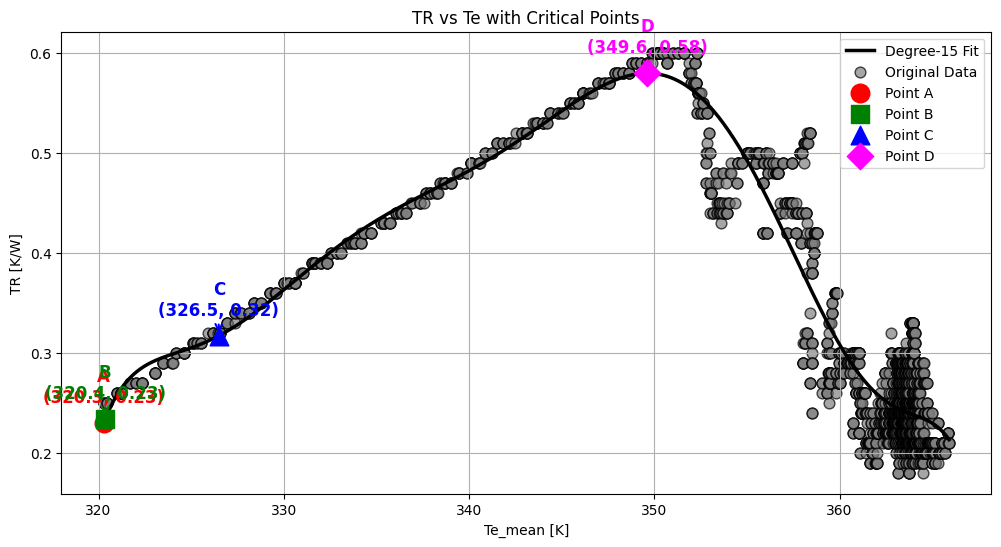

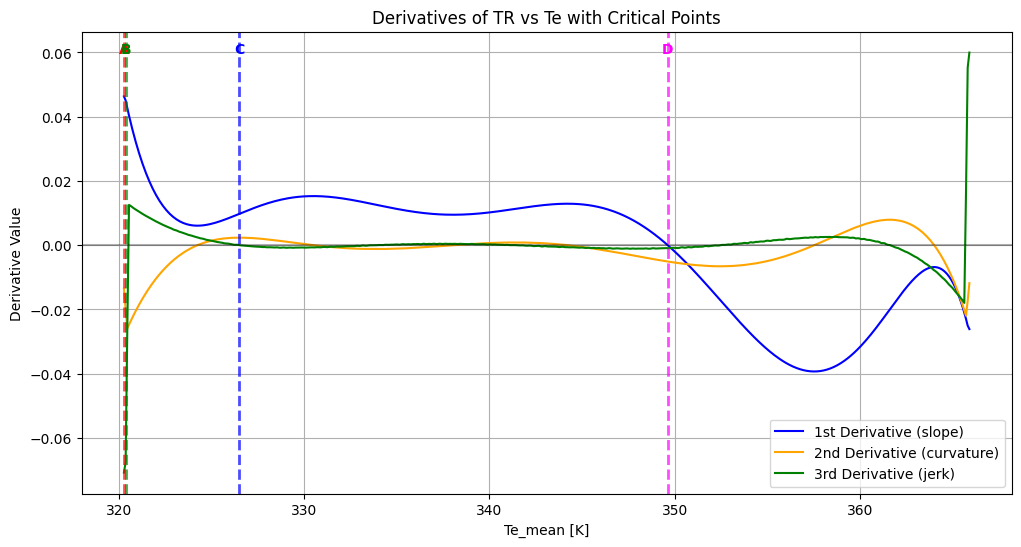

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

def optimize_polynomial_degree(Te, Y, max_degree=15, min_degree=5, cv_folds=5):
    degrees = range(min_degree, min(max_degree + 1, len(Te) // 3))
    rmse_scores, aic_scores, bic_scores, r2_scores = [], [], [], []
    Te_reshaped = Te.reshape(-1, 1)
    for degree in degrees:
        try:
            poly_pipeline = Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('linear', LinearRegression())
            ])
            cv_scores = cross_val_score(poly_pipeline, Te_reshaped, Y, cv=min(cv_folds, len(Te)//2), scoring='neg_root_mean_squared_error')
            rmse_cv = -cv_scores.mean()
            rmse_scores.append(rmse_cv)
            poly_pipeline.fit(Te_reshaped, Y)
            Y_pred = poly_pipeline.predict(Te_reshaped)
            mse = mean_squared_error(Y, Y_pred)
            n = len(Y)
            k = degree + 1
            ss_res = np.sum((Y - Y_pred) ** 2)
            ss_tot = np.sum((Y - np.mean(Y)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            r2_scores.append(r2)
            aic = n * np.log(mse) + 2 * k
            bic = n * np.log(mse) + k * np.log(n)
            aic_scores.append(aic)
            bic_scores.append(bic)
        except Exception:
            rmse_scores.append(float('inf'))
            aic_scores.append(float('inf'))
            bic_scores.append(float('inf'))
            r2_scores.append(-float('inf'))
    degrees = np.array(degrees)
    rmse_scores = np.array(rmse_scores)
    aic_scores = np.array(aic_scores)
    bic_scores = np.array(bic_scores)
    r2_scores = np.array(r2_scores)
    valid_idx = np.isfinite(rmse_scores)
    if not np.any(valid_idx):
        return {'optimal_degree': 5, 'method': 'default', 'rmse': float('inf')}
    best_rmse_idx = np.argmin(rmse_scores[valid_idx])
    best_aic_idx = np.argmin(aic_scores[valid_idx])
    best_bic_idx = np.argmin(bic_scores[valid_idx])
    best_rmse_degree = degrees[valid_idx][best_rmse_idx]
    best_aic_degree = degrees[valid_idx][best_aic_idx]
    best_bic_degree = degrees[valid_idx][best_bic_idx]
    rmse_norm = (rmse_scores - np.min(rmse_scores[valid_idx])) / (np.max(rmse_scores[valid_idx]) - np.min(rmse_scores[valid_idx]) + 1e-10)
    aic_norm = (aic_scores - np.min(aic_scores[valid_idx])) / (np.max(aic_scores[valid_idx]) - np.min(aic_scores[valid_idx]) + 1e-10)
    composite_scores = 0.6 * rmse_norm + 0.4 * aic_norm
    best_composite_idx = np.argmin(composite_scores[valid_idx])
    best_composite_degree = degrees[valid_idx][best_composite_idx]
    optimal_degree = best_composite_degree
    optimal_rmse = rmse_scores[valid_idx][best_composite_idx]
    optimal_r2 = r2_scores[valid_idx][best_composite_idx]
    return {
        'optimal_degree': int(optimal_degree),
        'method': 'composite_score',
        'rmse': optimal_rmse,
        'r2': optimal_r2,
        'degrees_tested': degrees[valid_idx].tolist(),
        'rmse_scores': rmse_scores[valid_idx].tolist(),
        'aic_scores': aic_scores[valid_idx].tolist(),
        'bic_scores': bic_scores[valid_idx].tolist(),
        'best_rmse_degree': int(best_rmse_degree),
        'best_aic_degree': int(best_aic_degree),
        'best_bic_degree': int(best_bic_degree)
    }

def _find_zero_crossings(arr):
    zero_crossings = []
    for i in range(len(arr) - 1):
        if arr[i] * arr[i + 1] < 0:
            zero_crossings.append(i)
    return np.array(zero_crossings)

def _identify_critical_points(Te_fine, Y_fit, d1, d2, d3, point_A_Te=None):
    if point_A_Te is not None:
        point_A_idx = np.argmin(np.abs(Te_fine - point_A_Te))
    else:
        point_A_idx = np.argmin(Y_fit)
    point_D_idx = np.argmax(Y_fit)
    if point_A_idx >= point_D_idx:
        point_A_idx = 0
    search_range = slice(point_A_idx + 1, point_D_idx)
    if search_range.start < search_range.stop:
        d1_search = d1[search_range]
        d2_search = d2[search_range]
        global_d1_max_idx = np.argmax(d1_search)
        global_d1_max_point = search_range.start + global_d1_max_idx
        d1_threshold = np.max(d1_search) * 0.75
        d1_candidates = np.where(d1_search >= d1_threshold)[0]
        best_B_score = float('inf')
        point_B_idx = global_d1_max_point
        d1_max = np.max(d1_search)
        d2_max_abs = np.max(np.abs(d2_search))
        for candidate in d1_candidates:
            actual_idx = search_range.start + candidate
            d1_val = d1[actual_idx]
            d2_val = abs(d2[actual_idx])
            d1_score = d1_val / d1_max
            d2_penalty = d2_val / (d2_max_abs + 1e-10)
            score = -(0.7 * d1_score) + (0.3 * d2_penalty)
            if score < best_B_score:
                best_B_score = score
                point_B_idx = actual_idx
        d3_search = d3[search_range]
        global_d2_max_idx = np.argmax(d2_search)
        global_d2_max_point = search_range.start + global_d2_max_idx
        d2_threshold = np.max(d2_search) * 0.75
        d2_candidates = np.where(d2_search >= d2_threshold)[0]
        best_C_score = float('inf')
        point_C_idx = global_d2_max_point
        d2_max = np.max(d2_search)
        d3_max_abs = np.max(np.abs(d3_search))
        for candidate in d2_candidates:
            actual_idx = search_range.start + candidate
            d2_val = d2[actual_idx]
            d3_val = abs(d3[actual_idx])
            d2_score = d2_val / d2_max
            d3_penalty = d3_val / (d3_max_abs + 1e-10)
            score = -(0.7 * d2_score) + (0.3 * d3_penalty)
            if score < best_C_score:
                best_C_score = score
                point_C_idx = actual_idx
    else:
        point_B_idx = point_A_idx + (point_D_idx - point_A_idx) // 3
        point_C_idx = point_A_idx + 2 * (point_D_idx - point_A_idx) // 3
    return {
        'A': point_A_idx,
        'B': point_B_idx,
        'C': point_C_idx,
        'D': point_D_idx
    }

def analyze_TR_vs_Te(csv_path, Q, FR, alpha, beta, te_min, te_max, poly_deg='auto', outlier_threshold=2.5, max_poly_deg=15, min_poly_deg=2, point_A_Te=None):
    df = pd.read_csv(csv_path)
    df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]
    df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()
    if df_filtered.empty or 'TR[K/W]' not in df_filtered.columns:
        print("No data found for given condition/range or missing TR[K/W] column.")
        return None
    df_tr_clean = df_filtered[np.abs(zscore(df_filtered['TR[K/W]'])) < outlier_threshold]
    Te = df_tr_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
    TR = df_tr_clean.sort_values('Te_mean[K]')['TR[K/W]'].values
    if len(Te) <= min_poly_deg:
        print("Insufficient TR data points for analysis.")
        return None
    if poly_deg == 'auto':
        opt_result = optimize_polynomial_degree(Te, TR, max_poly_deg, min_poly_deg)
        poly_deg = opt_result['optimal_degree']
    coeffs = np.polyfit(Te, TR, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    TR_fit = poly(Te_fine)
    d1 = np.gradient(TR_fit, Te_fine)
    d2 = np.gradient(d1, Te_fine)
    d3 = np.gradient(d2, Te_fine)
    points = _identify_critical_points(Te_fine, TR_fit, d1, d2, d3, point_A_Te)
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    plt.figure(figsize=(12, 6))
    plt.plot(Te_fine, TR_fit, label=f'Degree-{poly_deg} Fit', color='black', linewidth=2.5)
    plt.scatter(Te, TR, color='gray', alpha=0.7, s=60, edgecolor='k', label='Original Data')
    for label, idx in points.items():
        plt.scatter(Te_fine[idx], TR_fit[idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'Point {label}')
        plt.annotate(f'{label}\n({Te_fine[idx]:.1f}, {TR_fit[idx]:.2f})',
                    (Te_fine[idx], TR_fit[idx]),
                    textcoords="offset points", xytext=(0,15), ha='center',
                    fontsize=12, color=colors[label], fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    plt.xlabel('Te_mean [K]')
    plt.ylabel('TR [K/W]')
    plt.title('TR vs Te with Critical Points')
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(12, 6))
    plt.plot(Te_fine, d1, label='1st Derivative (slope)', color='blue')
    plt.plot(Te_fine, d2, label='2nd Derivative (curvature)', color='orange')
    plt.plot(Te_fine, d3, label='3rd Derivative (jerk)', color='green')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    for label, idx in points.items():
        plt.axvline(Te_fine[idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        plt.text(Te_fine[idx], plt.ylim()[1]*0.9, label, color=colors[label], fontweight='bold', ha='center')
    plt.xlabel('Te_mean [K]')
    plt.ylabel('Derivative Value')
    plt.title('Derivatives of TR vs Te with Critical Points')
    plt.legend()
    plt.grid(True)
    plt.show()
    return {
        'Te_original': Te,
        'TR_original': TR,
        'Te_fine': Te_fine,
        'TR_fit': TR_fit,
        'd1': d1,
        'd2': d2,
        'd3': d3,
        'points': points,
        'poly_coeffs': coeffs,
        'poly_degree': poly_deg
    }

# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 80, 60, 90, 0
te_min, te_max = 320, 390
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)

In [4]:
def _create_comprehensive_plots(results, Q, FR, alpha, beta):
    """Create comprehensive plots for the first relationship only (removes bottom blank plots)"""
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Heat Pipe Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    # Only plot the first analysis in results
    for analysis_type, data in results.items():
        if data is None:
            continue
        # Main relationship plot
        ax1 = axes[0]
        poly_deg = data.get('poly_degree', 'Unknown')
        rmse = data.get('rmse', 0)
        r2 = data.get('r2', 0)
        ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Degree-{poly_deg} Fit (R²={r2:.3f})')
        ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label='Original Data')
        fit_text = f'Polynomial: Degree {poly_deg}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}'
        ax1.text(0.02, 0.98, fit_text, transform=ax1.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        for label, idx in data['points'].items():
            ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{label}')
            ax1.annotate(f'{label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
        zero_crossings_d1 = _find_zero_crossings(data['d1'])
        zero_crossings_d2 = _find_zero_crossings(data['d2'])
        for zc in zero_crossings_d1[:3]:
            ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
        ax1.set_xlabel('Te_mean [K]', fontsize=14)
        ax1.set_ylabel(f'{data["y_label"]} [{data["y_unit"]}]', fontsize=14)
        ax1.set_title(f'{data["y_label"]} vs Te with Critical Points', fontsize=14)
        ax1.legend(fontsize=10, loc='best')
        ax1.grid(True, alpha=0.7)
        # Derivatives plot
        ax2 = axes[1]
        ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
        ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
        ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
        for label, idx in data['points'].items():
            ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
            ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, label, color=colors[label], fontweight='bold', ha='center')
        max_d1_idx = np.argmax(data['d1'])
        max_d2_idx = np.argmax(data['d2'])
        max_d3_idx = np.argmax(np.abs(data['d3']))
        ax2.scatter(data['Te_fine'][max_d1_idx], data['d1'][max_d1_idx], color='blue', s=100, marker='*', zorder=10, label=f'Max d1 @ {data["Te_fine"][max_d1_idx]:.1f}K')
        ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
        for zc in zero_crossings_d1[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
        for zc in zero_crossings_d2[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)
        ax2.set_xlabel('Te_mean [K]', fontsize=14)
        ax2.set_ylabel('Derivative Value', fontsize=14)
        ax2.set_title(f'Derivatives of {data["y_label"]} vs Te', fontsize=14)
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.7)
        break  # Only plot the first analysis
    plt.tight_layout()
    plt.show()

## 80 W

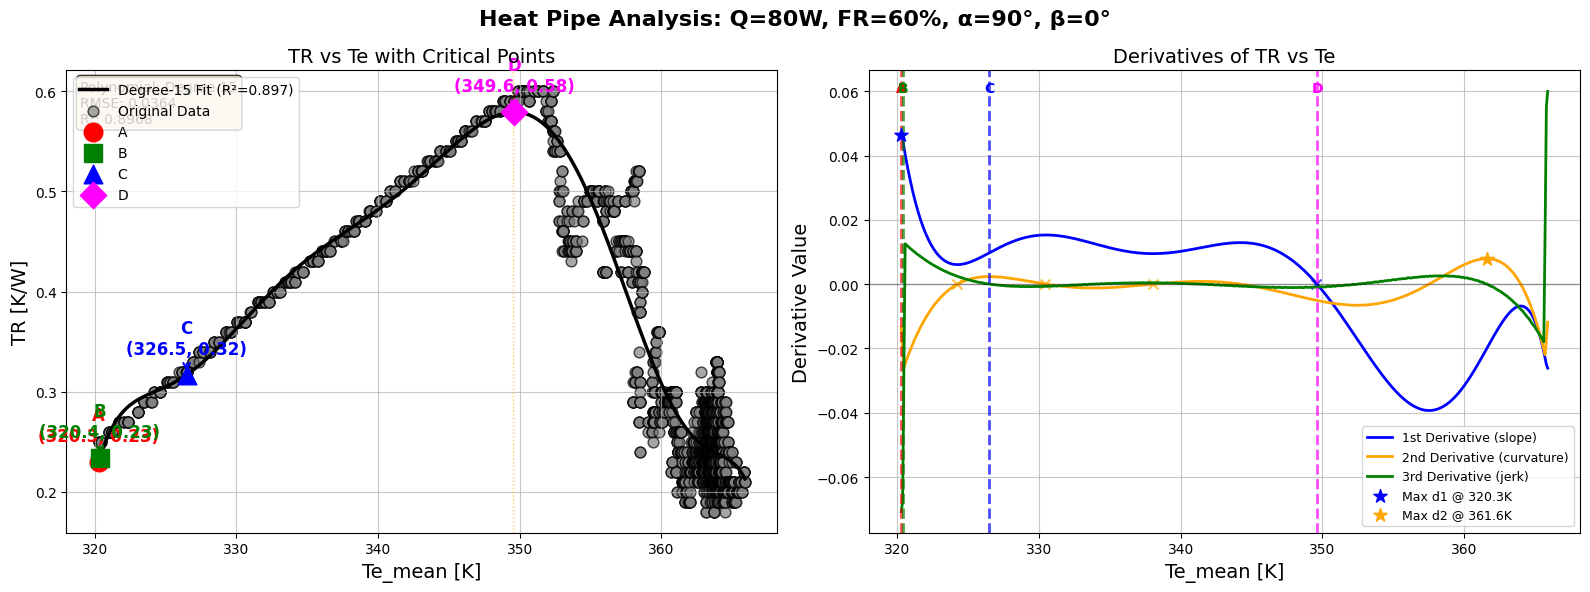

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

def optimize_polynomial_degree(Te, Y, max_degree=15, min_degree=5, cv_folds=5):
    degrees = range(min_degree, min(max_degree + 1, len(Te) // 3))
    rmse_scores, aic_scores, bic_scores, r2_scores = [], [], [], []
    Te_reshaped = Te.reshape(-1, 1)
    for degree in degrees:
        try:
            poly_pipeline = Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('linear', LinearRegression())
            ])
            cv_scores = cross_val_score(poly_pipeline, Te_reshaped, Y, cv=min(cv_folds, len(Te)//2), scoring='neg_root_mean_squared_error')
            rmse_cv = -cv_scores.mean()
            rmse_scores.append(rmse_cv)
            poly_pipeline.fit(Te_reshaped, Y)
            Y_pred = poly_pipeline.predict(Te_reshaped)
            mse = mean_squared_error(Y, Y_pred)
            n = len(Y)
            k = degree + 1
            ss_res = np.sum((Y - Y_pred) ** 2)
            ss_tot = np.sum((Y - np.mean(Y)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            r2_scores.append(r2)
            aic = n * np.log(mse) + 2 * k
            bic = n * np.log(mse) + k * np.log(n)
            aic_scores.append(aic)
            bic_scores.append(bic)
        except Exception:
            rmse_scores.append(float('inf'))
            aic_scores.append(float('inf'))
            bic_scores.append(float('inf'))
            r2_scores.append(-float('inf'))
    degrees = np.array(degrees)
    rmse_scores = np.array(rmse_scores)
    aic_scores = np.array(aic_scores)
    bic_scores = np.array(bic_scores)
    r2_scores = np.array(r2_scores)
    valid_idx = np.isfinite(rmse_scores)
    if not np.any(valid_idx):
        return {'optimal_degree': 5, 'method': 'default', 'rmse': float('inf')}
    best_rmse_idx = np.argmin(rmse_scores[valid_idx])
    best_aic_idx = np.argmin(aic_scores[valid_idx])
    best_bic_idx = np.argmin(bic_scores[valid_idx])
    best_rmse_degree = degrees[valid_idx][best_rmse_idx]
    best_aic_degree = degrees[valid_idx][best_aic_idx]
    best_bic_degree = degrees[valid_idx][best_bic_idx]
    rmse_norm = (rmse_scores - np.min(rmse_scores[valid_idx])) / (np.max(rmse_scores[valid_idx]) - np.min(rmse_scores[valid_idx]) + 1e-10)
    aic_norm = (aic_scores - np.min(aic_scores[valid_idx])) / (np.max(aic_scores[valid_idx]) - np.min(aic_scores[valid_idx]) + 1e-10)
    composite_scores = 0.6 * rmse_norm + 0.4 * aic_norm
    best_composite_idx = np.argmin(composite_scores[valid_idx])
    best_composite_degree = degrees[valid_idx][best_composite_idx]
    optimal_degree = best_composite_degree
    optimal_rmse = rmse_scores[valid_idx][best_composite_idx]
    optimal_r2 = r2_scores[valid_idx][best_composite_idx]
    return {
        'optimal_degree': int(optimal_degree),
        'method': 'composite_score',
        'rmse': optimal_rmse,
        'r2': optimal_r2,
        'degrees_tested': degrees[valid_idx].tolist(),
        'rmse_scores': rmse_scores[valid_idx].tolist(),
        'aic_scores': aic_scores[valid_idx].tolist(),
        'bic_scores': bic_scores[valid_idx].tolist(),
        'best_rmse_degree': int(best_rmse_degree),
        'best_aic_degree': int(best_aic_degree),
        'best_bic_degree': int(best_bic_degree)
    }

def _find_zero_crossings(arr):
    zero_crossings = []
    for i in range(len(arr) - 1):
        if arr[i] * arr[i + 1] < 0:
            zero_crossings.append(i)
    return np.array(zero_crossings)

def _identify_critical_points(Te_fine, Y_fit, d1, d2, d3, point_A_Te=None):
    if point_A_Te is not None:
        point_A_idx = np.argmin(np.abs(Te_fine - point_A_Te))
    else:
        point_A_idx = np.argmin(Y_fit)
    point_D_idx = np.argmax(Y_fit)
    if point_A_idx >= point_D_idx:
        point_A_idx = 0
    search_range = slice(point_A_idx + 1, point_D_idx)
    if search_range.start < search_range.stop:
        d1_search = d1[search_range]
        d2_search = d2[search_range]
        global_d1_max_idx = np.argmax(d1_search)
        global_d1_max_point = search_range.start + global_d1_max_idx
        d1_threshold = np.max(d1_search) * 0.75
        d1_candidates = np.where(d1_search >= d1_threshold)[0]
        best_B_score = float('inf')
        point_B_idx = global_d1_max_point
        d1_max = np.max(d1_search)
        d2_max_abs = np.max(np.abs(d2_search))
        for candidate in d1_candidates:
            actual_idx = search_range.start + candidate
            d1_val = d1[actual_idx]
            d2_val = abs(d2[actual_idx])
            d1_score = d1_val / d1_max
            d2_penalty = d2_val / (d2_max_abs + 1e-10)
            score = -(0.7 * d1_score) + (0.3 * d2_penalty)
            if score < best_B_score:
                best_B_score = score
                point_B_idx = actual_idx
        d3_search = d3[search_range]
        global_d2_max_idx = np.argmax(d2_search)
        global_d2_max_point = search_range.start + global_d2_max_idx
        d2_threshold = np.max(d2_search) * 0.75
        d2_candidates = np.where(d2_search >= d2_threshold)[0]
        best_C_score = float('inf')
        point_C_idx = global_d2_max_point
        d2_max = np.max(d2_search)
        d3_max_abs = np.max(np.abs(d3_search))
        for candidate in d2_candidates:
            actual_idx = search_range.start + candidate
            d2_val = d2[actual_idx]
            d3_val = abs(d3[actual_idx])
            d2_score = d2_val / d2_max
            d3_penalty = d3_val / (d3_max_abs + 1e-10)
            score = -(0.7 * d2_score) + (0.3 * d3_penalty)
            if score < best_C_score:
                best_C_score = score
                point_C_idx = actual_idx
    else:
        point_B_idx = point_A_idx + (point_D_idx - point_A_idx) // 3
        point_C_idx = point_A_idx + 2 * (point_D_idx - point_A_idx) // 3
    return {
        'A': point_A_idx,
        'B': point_B_idx,
        'C': point_C_idx,
        'D': point_D_idx
    }

def analyze_TR_vs_Te(csv_path, Q, FR, alpha, beta, te_min, te_max, poly_deg='auto', outlier_threshold=2.5, max_poly_deg=15, min_poly_deg=2, point_A_Te=None):
    df = pd.read_csv(csv_path)
    df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]
    df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()
    if df_filtered.empty or 'TR[K/W]' not in df_filtered.columns:
        print("No data found for given condition/range or missing TR[K/W] column.")
        return None
    df_tr_clean = df_filtered[np.abs(zscore(df_filtered['TR[K/W]'])) < outlier_threshold]
    Te = df_tr_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
    TR = df_tr_clean.sort_values('Te_mean[K]')['TR[K/W]'].values
    if len(Te) <= min_poly_deg:
        print("Insufficient TR data points for analysis.")
        return None
    if poly_deg == 'auto':
        opt_result = optimize_polynomial_degree(Te, TR, max_poly_deg, min_poly_deg)
        poly_deg = opt_result['optimal_degree']
    coeffs = np.polyfit(Te, TR, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    TR_fit = poly(Te_fine)
    d1 = np.gradient(TR_fit, Te_fine)
    d2 = np.gradient(d1, Te_fine)
    d3 = np.gradient(d2, Te_fine)
    points = _identify_critical_points(Te_fine, TR_fit, d1, d2, d3, point_A_Te)
    # For compatibility with _create_comprehensive_plots, use 'Y_fit', 'Y_original', etc.
    return {
        'Te_original': Te,
        'Y_original': TR,
        'Te_fine': Te_fine,
        'Y_fit': TR_fit,
        'd1': d1,
        'd2': d2,
        'd3': d3,
        'points': points,
        'poly_coeffs': coeffs,
        'poly_degree': poly_deg,
        'y_label': 'TR',
        'y_unit': 'K/W',
        'rmse': np.sqrt(mean_squared_error(TR, poly(Te))),
        'r2': 1 - np.sum((TR - poly(Te)) ** 2) / np.sum((TR - np.mean(TR)) ** 2)
    }

def _create_comprehensive_plots(results, Q, FR, alpha, beta):
    """Create comprehensive plots for the first relationship only (removes bottom blank plots)"""
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Heat Pipe Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    # Only plot the first analysis in results
    for analysis_type, data in results.items():
        if data is None:
            continue
        # Main relationship plot
        ax1 = axes[0]
        poly_deg = data.get('poly_degree', 'Unknown')
        rmse = data.get('rmse', 0)
        r2 = data.get('r2', 0)
        ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Degree-{poly_deg} Fit (R²={r2:.3f})')
        ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label='Original Data')
        fit_text = f'Polynomial: Degree {poly_deg}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}'
        ax1.text(0.02, 0.98, fit_text, transform=ax1.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        for label, idx in data['points'].items():
            ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{label}')
            ax1.annotate(f'{label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
        zero_crossings_d1 = _find_zero_crossings(data['d1'])
        zero_crossings_d2 = _find_zero_crossings(data['d2'])
        for zc in zero_crossings_d1[:3]:
            ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
        ax1.set_xlabel('Te_mean [K]', fontsize=14)
        ax1.set_ylabel(f'{data["y_label"]} [{data["y_unit"]}]', fontsize=14)
        ax1.set_title(f'{data["y_label"]} vs Te with Critical Points', fontsize=14)
        ax1.legend(fontsize=10, loc='best')
        ax1.grid(True, alpha=0.7)
        # Derivatives plot
        ax2 = axes[1]
        ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
        ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
        ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
        for label, idx in data['points'].items():
            ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
            ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, label, color=colors[label], fontweight='bold', ha='center')
        max_d1_idx = np.argmax(data['d1'])
        max_d2_idx = np.argmax(data['d2'])
        max_d3_idx = np.argmax(np.abs(data['d3']))
        ax2.scatter(data['Te_fine'][max_d1_idx], data['d1'][max_d1_idx], color='blue', s=100, marker='*', zorder=10, label=f'Max d1 @ {data["Te_fine"][max_d1_idx]:.1f}K')
        ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
        for zc in zero_crossings_d1[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
        for zc in zero_crossings_d2[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)
        ax2.set_xlabel('Te_mean [K]', fontsize=14)
        ax2.set_ylabel('Derivative Value', fontsize=14)
        ax2.set_title(f'Derivatives of {data["y_label"]} vs Te', fontsize=14)
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.7)
        break  # Only plot the first analysis
    plt.tight_layout()
    plt.show()

# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 80, 60, 90, 0
te_min, te_max = 320, 390
results_TR = {'TR_analysis': analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)}
_create_comprehensive_plots(results_TR, Q, FR, alpha, beta)

## 100 W

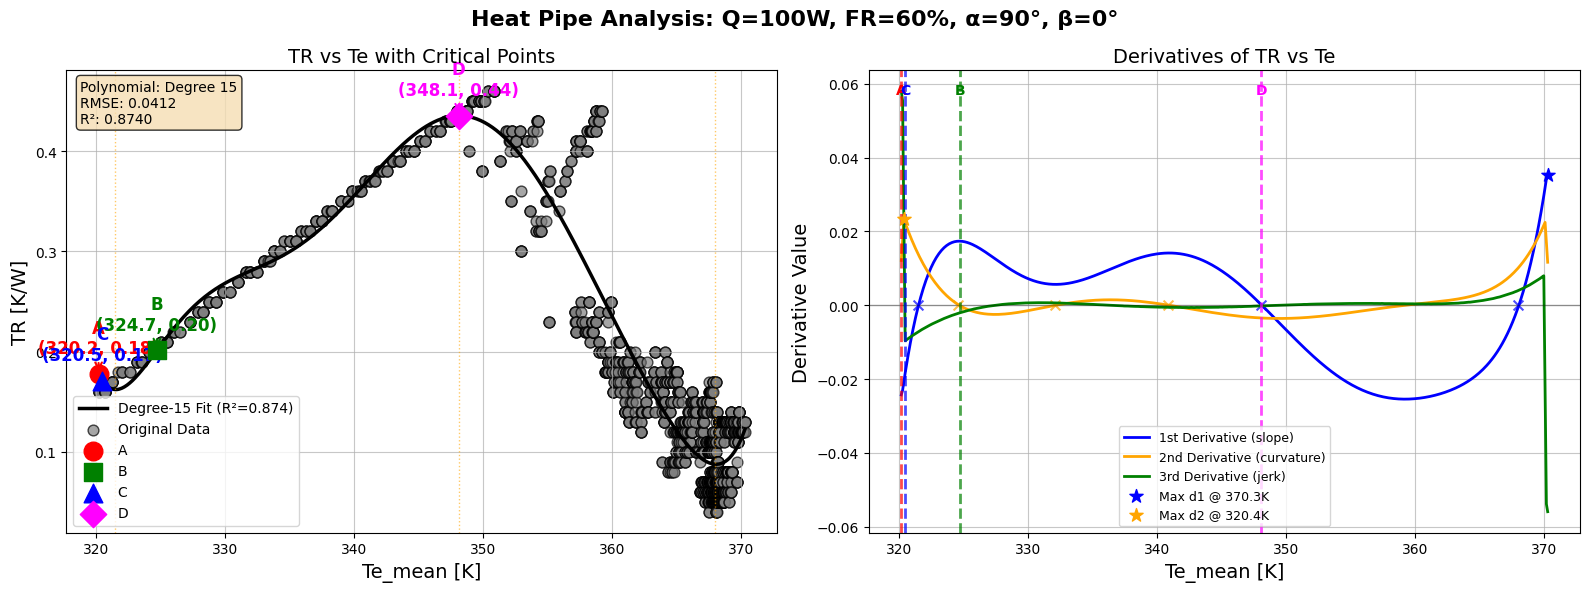

In [6]:
csv_path = 'database.csv'
Q, FR, alpha, beta = 100, 60, 90, 0
te_min, te_max = 320, 390
results_TR = {'TR_analysis': analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)}
_create_comprehensive_plots(results_TR, Q, FR, alpha, beta)

## 120 W

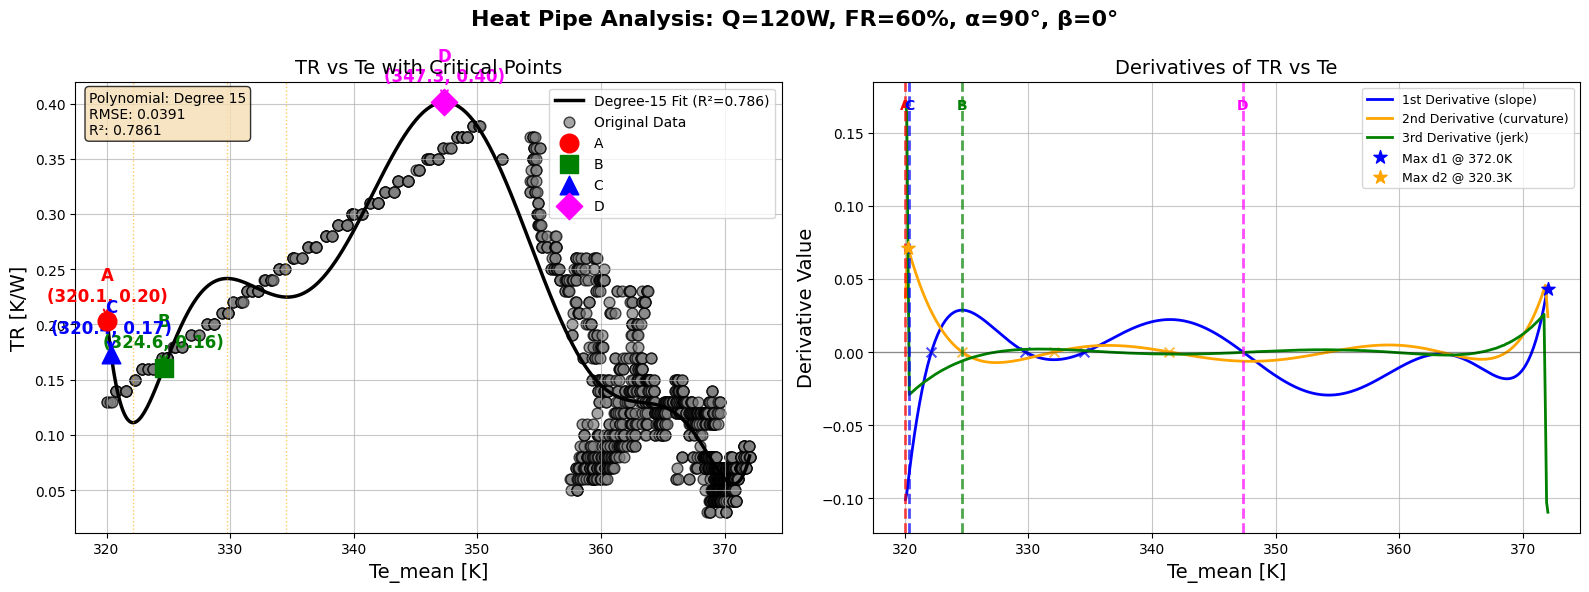

In [7]:
csv_path = 'database.csv'
Q, FR, alpha, beta = 120, 60, 90, 0
te_min, te_max = 320, 390
results_TR = {'TR_analysis': analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)}
_create_comprehensive_plots(results_TR, Q, FR, alpha, beta)

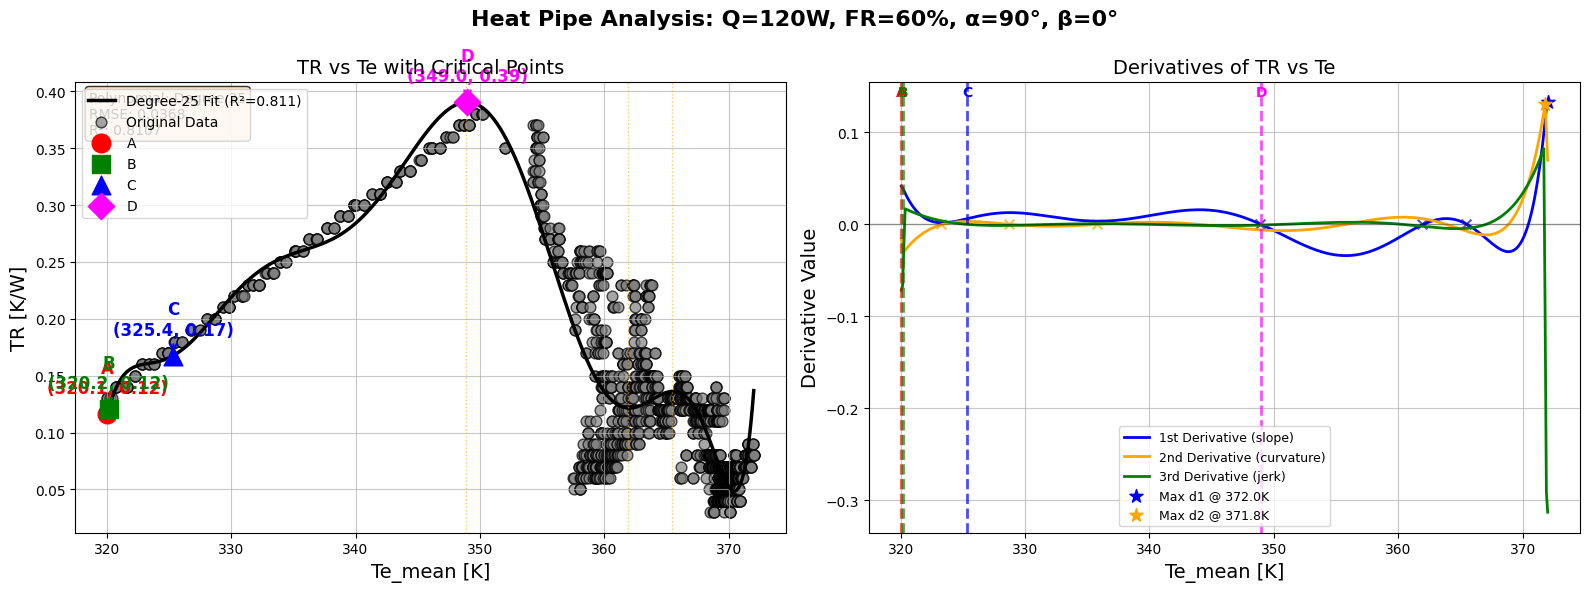

In [8]:
csv_path = 'database.csv'
Q, FR, alpha, beta = 120, 60, 90, 0
te_min, te_max = 320, 390
results_TR = {'TR_analysis': analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=25,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)}
_create_comprehensive_plots(results_TR, Q, FR, alpha, beta)